In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from torchvision.transforms import functional as TF
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Image as IPImage
import gc
import matplotlib.colors as mcolors


from wiring_efficiency_utils import *
from audiosheet import *
from map_plotting import *
from fig_plots import *

In [2]:
def fit_gaussian_2d(
    maps,
    eps: float = 1e-8,
    edge_margin: int = 0
):
    """
    Fits 2D Gaussians to [B,1,W,H] maps and returns:
      µx, µy, θ_norm
    where θ_norm is the orientation computed after 'whitening'
    by the *average* x and y spreads across the batch.

    Args
    ----
    maps        : Tensor[B,1,W,H] of non-negative weights
    eps         : stability term
    edge_margin : optional border margin to zero out

    Returns
    -------
    Tensor[B,3] : (µx, µy, θ_norm)
    """
    assert maps.ndim == 4 and maps.shape[1] == 1
    B, _, W, H = maps.shape
    device, dtype = maps.device, maps.dtype

    if edge_margin > 0:
        maps = maps.clone()
        maps[:, :, :edge_margin, :] = 0
        maps[:, :, -edge_margin:, :] = 0
        maps[:, :, :, :edge_margin] = 0
        maps[:, :, :, -edge_margin:] = 0

    # Coordinates
    xs = torch.arange(W, device=device, dtype=dtype).view(1, 1, W, 1)
    ys = torch.arange(H, device=device, dtype=dtype).view(1, 1, 1, H)

    weight = maps.sum(dim=(-1, -2), keepdim=True).clamp_min(eps)
    μx = (maps * xs).sum(dim=(-1, -2), keepdim=True) / weight
    μy = (maps * ys).sum(dim=(-1, -2), keepdim=True) / weight

    dx, dy = xs - μx, ys - μy
    norm = weight.squeeze(-1).squeeze(-1)

    Cxx = (maps * dx * dx).sum(dim=(-1, -2)) / norm
    Cyy = (maps * dy * dy).sum(dim=(-1, -2)) / norm
    Cxy = (maps * dx * dy).sum(dim=(-1, -2)) / norm

    # --- Normalisation step ---
    # Compute global average spreads along x and y
    avg_Cxx = Cxx.mean()
    avg_Cyy = Cyy.mean()

    # Build whitened covariance entries for each Gaussian
    # Scaling so that average variance is 1
    Cxx_w = Cxx / avg_Cxx
    Cyy_w = Cyy / avg_Cyy
    Cxy_w = Cxy / torch.sqrt(avg_Cxx * avg_Cyy)

    # Orientation using the whitened covariance
    θ_norm = 0.5 * torch.atan2(2 * Cxy_w, Cxx_w - Cyy_w)

    return torch.stack((μx[:,0,0], μy[:,0,0], θ_norm), dim=-1)

def center_of_mass_polar(x):
    """
    x: Tensor of shape [b, 1, w, h]
    Returns: Two tensors of shape [b, 1, 1, 1]:
        angles (radians) and magnitudes (distance from center in pixels).
    """
    b, c, w, h = x.shape
    assert c == 1, "Channel dimension must be 1"

    # Coordinate grids (y goes 0..w-1, x goes 0..h-1)
    ys = torch.arange(w, device=x.device).float()
    xs = torch.arange(h, device=x.device).float()
    yy, xx = torch.meshgrid(ys, xs, indexing='ij')  # shape [w, h]

    # Total "mass" per batch
    mass = x.sum(dim=(2, 3), keepdim=True) + 1e-8  # avoid div by zero

    # Center of mass coordinates
    com_y = (x.squeeze(1) * yy).sum(dim=(1, 2), keepdim=True) / mass.squeeze(1)
    com_x = (x.squeeze(1) * xx).sum(dim=(1, 2), keepdim=True) / mass.squeeze(1)

    # Relative coordinates from the image center
    center_y = (w - 1) / 2.0
    center_x = (h - 1) / 2.0
    rel_y = com_y - center_y  # shape [b,1,1]
    rel_x = com_x - center_x  # shape [b,1,1]

    # Compute polar coordinates
    angles = torch.atan2(rel_y, rel_x)                     # radians, [-pi, pi]
    magnitudes = torch.sqrt(rel_y**2 + rel_x**2)           # pixels

    return angles.view(b, 1, 1, 1), magnitudes.view(b, 1, 1, 1)

def plot_grid(items):

    side = int(np.sqrt(items.shape[0]))
    grid = items.view(side, side, items.shape[-2], items.shape[-1])
    grid = grid.permute(0,2,1,3).reshape(side*items.shape[-2], side*items.shape[-1])
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.imshow(grid[px:px+ps,py:py+ps])
    plt.show()

In [3]:
torch.cuda.empty_cache()
X = torch.load('./x_processed_32_high.pt')
X /= X.mean([0,2], keepdim=True)
X /= X.max()
#X = F.interpolate(X[:,None], scale_factor=(2,1), mode='bilinear')[:,0]
print(X.shape)
#X0 = torch.load('./x_processed_16_gc.pt').cuda()

channels = X.shape[1]
time_window = 32
R_rf = 11
time_px = 11
R_pat = 7
size = 36

iterations = 10000
batch_size = 16  # Number of crops to load at once
device = 'cuda'  # Assuming CUDA is available and desired
beta = 1 - 3e-4

torch.Size([2000, 90, 2500])


In [4]:
loss_beta = 1e-2
nn_time_stride = 4
nn_space_stride = 3
nn_batch_size = 16

KEEP = False
if not KEEP:
    model = NeuralSheet(size, channels, time_window, time_px, R_rf, R_pat, device=device).to(device)
    lr = 1e-3
    network = init_nn_audio((size//nn_space_stride)**2 * (time_window//nn_time_stride), channels*time_window)
    avg_loss = 0

    batch_responses = torch.zeros(size, size, time_window).to(device)
    
    dynamic_batch = torch.zeros(iterations, 1, 1, (size//nn_space_stride) * (size//nn_space_stride) * (time_window//nn_time_stride))
    dynamic_targets = torch.zeros(iterations, 1, channels, time_window)

    count = 0

batch_progress = tqdm(range(iterations), leave=False)
for i in batch_progress:

    b_idx = torch.randint(X.shape[0] - batch_size, (1,))
    t_idx = torch.randint(X.shape[2] - time_window*2, (1,))

    #batch = X[b_idx:b_idx+batch_size, :, t_idx:t_idx+time_window]

    batch = X[b_idx]
    batch = batch.to('cuda')  # Transfer the entire batch to GPU

    batch_responses *= 0

    model.hebbian_lr = lr
    model.homeo_lr = lr
    limit = 1e-4
    lr *= beta
    lr = lr if lr>limit else limit

    if batch[0, :, t_idx+time_window:t_idx+time_window*2].mean() > 0.05:

        #for signal in batch:
        for t in range(time_window):
    
            signal = batch[0, :, t_idx+t:t_idx+t+time_window]
            
            model(signal)
            model.hebbian_step()
    
            batch_responses[:, :, t] = model.current_response[0,0]
            
    
        dynamic_targets[count,0] = signal.clone() + 0
        dynamic_batch[count,0] = batch_responses[::nn_space_stride,::nn_space_stride,::nn_time_stride].reshape(1,-1) + 1e-11
        count += 1
    
        if count > nn_batch_size:
    
            takes = torch.randperm(count)[:nn_batch_size]
    
            curr_batch = dynamic_batch[takes].to(device)
            curr_targets = dynamic_targets[takes].to(device)
            
            reco_input = network['activ'](network['model'](curr_batch)).view(curr_targets.shape)
        
            loss, loss_std = nn_loss(network, curr_targets, reco_input)
            
            sim = cosim(curr_targets.detach().cpu(), reco_input.detach().cpu(), True)
                            
            avg_loss = (1-loss_beta)*avg_loss + loss_beta*sim
            
            network['optim'].zero_grad()
            loss.backward()
            network['optim'].step()
        
            mean_activation = model.mean_activations.mean()
            mean_std = model.mean_activations.std() / model.homeo_target
            
            batch_progress.set_description('M:{:.3f} STD:{:.3f} BCE:{:.3f} LR:{:.5f} AFF:{:.3f} GAI:{:.3f} THR:{:.3f}'.format(
                mean_activation, 
                mean_std, 
                avg_loss,
                lr,
                model.aff_strength,
                model.gains.mean(),
                model.thresholds.mean()
            ))


/home/nicolamendini/jupyter_env/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


strides:  tensor(1., device='cuda:0') tensor(2.8182, device='cuda:0')


KeyboardInterrupt: 

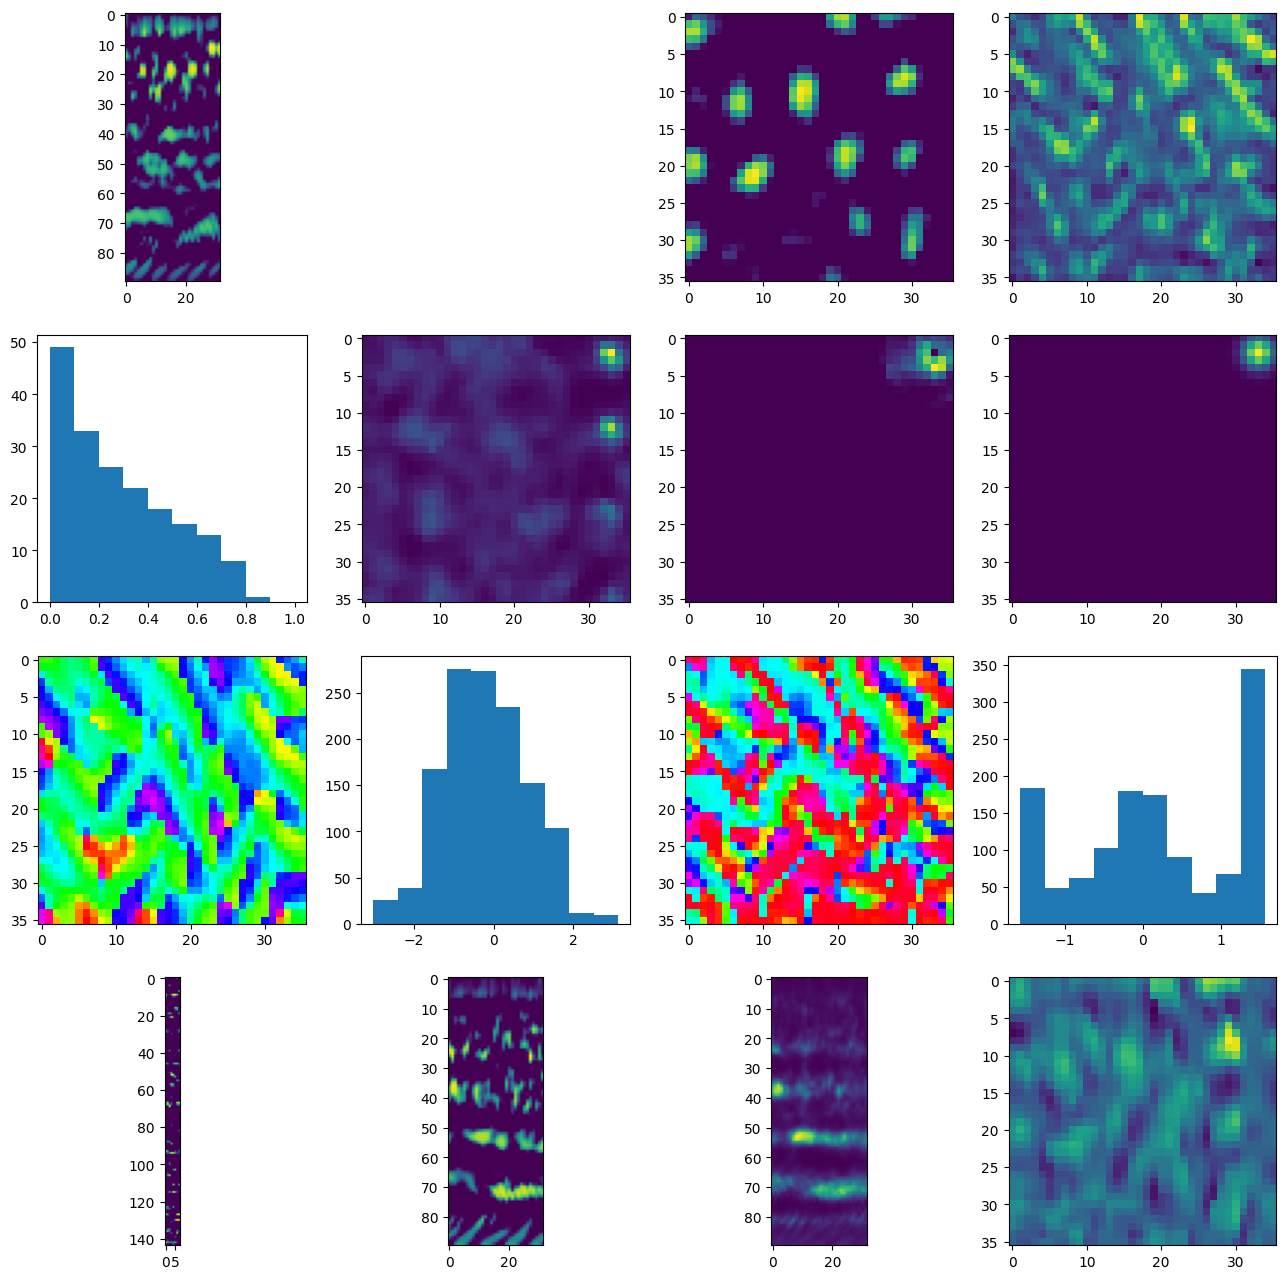

In [5]:
torch.cuda.empty_cache()
gc.collect()

random_sample = random.randint(0, model.afferent_weights.shape[0] - 1)
random_batch = random.randint(0, batch_size - 1)

b_idx = torch.randint(X.shape[0] - batch_size, (1,))
t_idx = torch.randint(X.shape[2] - time_window, (1,))

batch = X[b_idx:b_idx+batch_size, :, t_idx:t_idx+time_window]
batch = batch.to('cuda')  # Transfer the entire batch to GPU
signal = batch[random_batch]
model(signal)

nn_input = curr_batch[0][None]
reco_input = network['activ'](network['model'](nn_input)).view(signal.shape).cpu()

targets = curr_targets[0]

plt.figure(figsize=(16,16))
plt.subplot(4,4,1)
plt.imshow(signal.detach().cpu())
plt.subplot(4,4,3)
plt.imshow(model.current_response[0,0].cpu())
plt.subplot(4,4,4)
plt.imshow(model.thresholds[0,0].cpu())
plt.subplot(4,4,5)
plt.stairs(model.avg_hist.int(), torch.linspace(0,1,11), fill=True)
plt.subplot(4,4,6)
plt.imshow(model.lateral_correlations[random_sample,0].detach().cpu())
plt.subplot(4,4,7)
plt.imshow(model.mid_range_inh[random_sample,0].detach().cpu())
plt.subplot(4,4,8)
plt.imshow(model.lateral_weights_exc[random_sample,0].cpu())

a = model.get_aff_weights().cpu()
a = torch.relu(a[:,0] - a[:,1])[:,None]
a /= a.sum([2,3], keepdim=True)
vals = fit_gaussian_2d(a)
vals.shape

angles, magnitudes = center_of_mass_polar(a.view(-1, 1, a.shape[-2], a.shape[-1]))
angles = angles.view(size,size).cpu()
magnitudes = magnitudes.view(size,size).cpu() / magnitudes.max()
plt.subplot(4,4,9)
plt.imshow(angles, cmap='hsv')
plt.subplot(4,4,10)
plt.hist(angles.flatten().cpu())
plt.subplot(4,4,11)
whitened_angle = vals[:,:,2].cpu().view(size,size)
plt.imshow(whitened_angle, cmap='hsv')
plt.subplot(4,4,12)
plt.hist(whitened_angle.flatten().cpu())

plt.subplot(4,4,13)
plt.imshow(nn_input.mean(0).view(-1, time_window//nn_time_stride).cpu())
plt.subplot(4,4,14)
plt.imshow(targets.cpu()[0])
plt.subplot(4,4,15)
plt.imshow(reco_input.detach().cpu())
plt.subplot(4,4,16)
plt.imshow(model.current_afferent[0,0].cpu())

array = model.response_tracker.cpu()[:,0]
array[:,0,0] = 1
anim = animate(array, model.response_tracker.shape[0])
anim

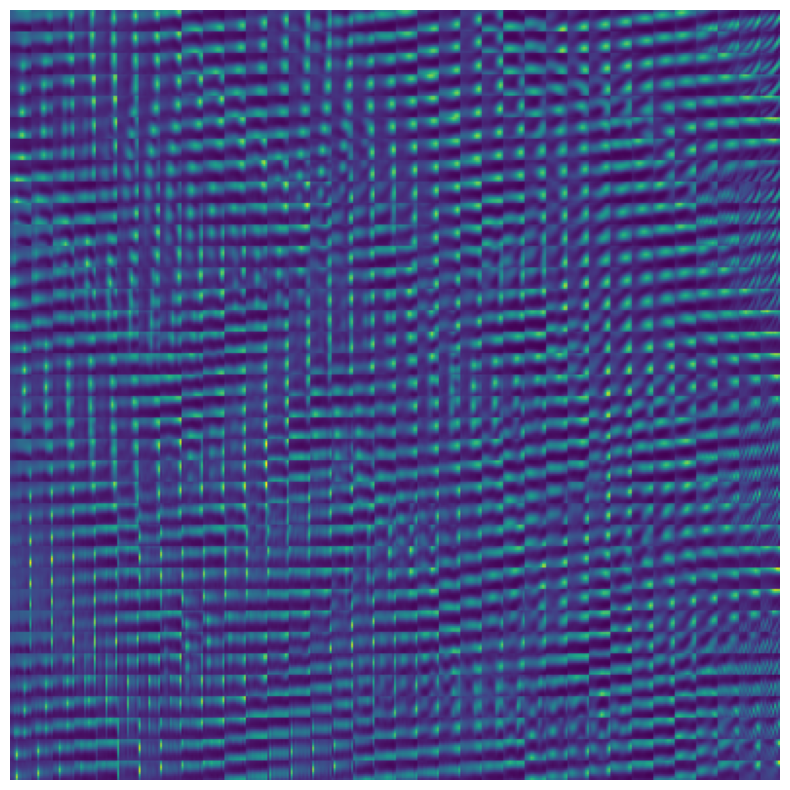

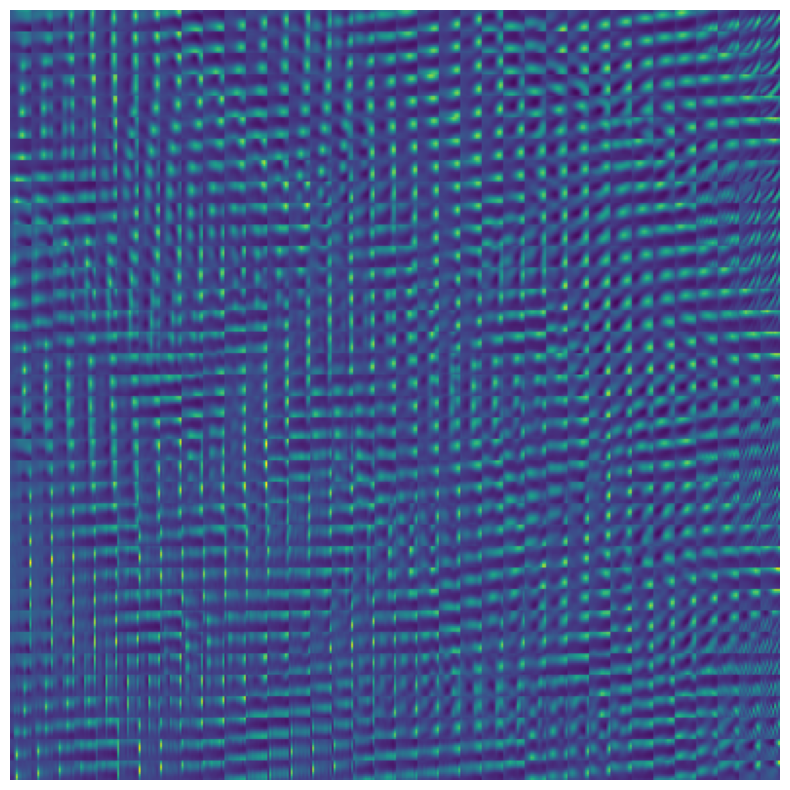

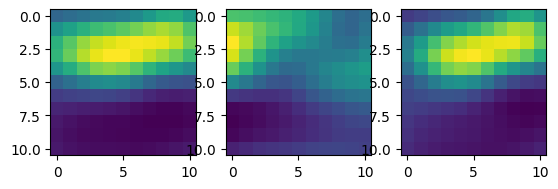

In [10]:
random_sample = random.randint(0, model.afferent_weights.shape[0] - 1)
a = model.get_aff_weights().cpu()
#a = a[:,1]
#a = (a[:,1])
px_stride = 10
px = 0
py = px
ps = -1
#a = a / (a.view(size**2, 1, 1, -1).max(3, keepdim=True)[0] + 1e-11)
plot_grid(a[:,0])
plot_grid(a[:,0] - a[:,1])
plt.subplot(1,3,1)
plt.imshow(model.get_aff_weights()[random_sample,0].cpu())
plt.subplot(1,3,2)
plt.imshow(model.get_aff_weights()[random_sample,1].cpu())
plt.subplot(1,3,3)
plt.imshow(model.get_aff_weights()[random_sample,0].cpu() - model.get_aff_weights()[random_sample,1].cpu())

In [141]:
torch.cuda.empty_cache()
gc.collect()

dim_window = 12

inputs = []
for b_idx in tqdm(range(channels*dim_window)):
    
    b_idx = torch.randint(X.shape[0] - 1, (1,))
    t_idx = torch.randint(X.shape[2] - dim_window, (1,))

    batch = X[b_idx:b_idx+1, :, t_idx:t_idx+dim_window]
    batch = batch.to('cuda')

    inputs.append(batch)

inputs = torch.cat(inputs, dim=0)
eff_dim, comp_sampled = get_pca_dimensions(inputs, 3)

print('dim: ', eff_dim)

100%|████████████████████████████████████| 1080/1080 [00:00<00:00, 40323.38it/s]


measuring dimensionality, number of Nan found: 0
dim:  220


In [143]:
reduced_time = (dim_window // nn_time_stride)
reduced_space = (size // nn_space_stride)**2
code_block_size = reduced_space * reduced_time
blocks_per_item = time_window // dim_window
n_items = code_block_size // blocks_per_item + 1
codes = dynamic_batch[count-n_items:count].view(n_items, 1, reduced_space, time_window // nn_time_stride)
codes = F.unfold(codes, kernel_size=(reduced_space,reduced_time), stride=(reduced_space,reduced_time)).permute(0,2,1).reshape(-1, reduced_space, reduced_time)

print(codes.shape)

eff_dim, comp_sampled = get_pca_dimensions(codes, 3)
print('dimensionality: ', eff_dim, 'selected_items: ', n_items, 'total counts: ', count)

torch.Size([434, 144, 3])
measuring dimensionality, number of Nan found: 0
dimensionality:  206 selected_items:  217 total counts:  1468


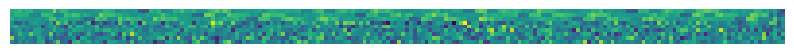

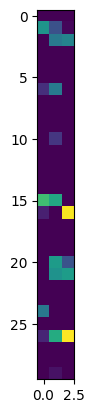

In [37]:
plot_grid(comp_sampled.view(-1, 1, 9, code_block_size))
plt.imshow(codes[100, :30])
plt.show()

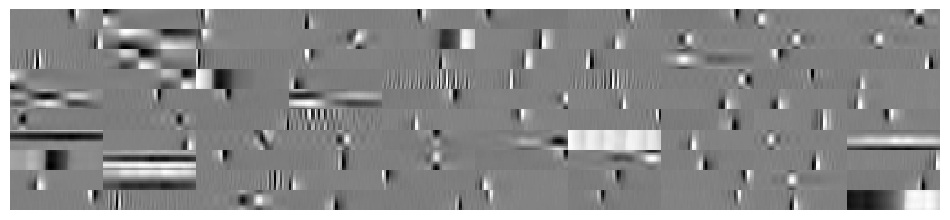

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import FastICA

def apply_ica_and_plot(X, n_components=None, device='cuda'):
    """
    Applies ICA on a tensor X of shape [b, w, h] and plots the learned filters
    as a single tiled image.
    
    Args:
        X (torch.Tensor): Input data of shape [b, w, h].
        n_components (int): Number of independent components to extract.
                            Defaults to min(b, w*h).
        device (str): 'cuda' or 'cpu'.
    """
    X = X.to(device)
    b, w, h = X.shape
    
    # Flatten samples
    X_flat = X.view(b, -1)
    X_np = X_flat.detach().cpu().numpy()
    
    if n_components is None:
        n_components = min(b, w * h)
    
    # ICA
    ica = FastICA(n_components=n_components, whiten='unit-variance', max_iter=1000, random_state=0)
    S = ica.fit_transform(X_np)
    A = ica.mixing_  # Shape: [w*h, n_components]
    
    # Reshape filters
    filters = A.T.reshape(n_components, w, h)  # [n_components, w, h]
    
    # Normalize each filter (optional for visualization)
    filters = filters / (np.abs(filters).max(axis=(1,2), keepdims=True) + 1e-11)
    
    # Arrange filters into a square-ish grid
    grid_size = int(np.ceil(np.sqrt(n_components)))
    pad_w = grid_size * w
    pad_h = grid_size * h
    tiled = np.zeros((pad_w, pad_h))
    
    idx = 0
    for i in range(grid_size):
        for j in range(grid_size):
            if idx < n_components:
                tiled[i*w:(i+1)*w, j*h:(j+1)*h] = filters[idx]
                idx += 1
    
    # Plot as a single image
    plt.figure(figsize=(12, 12))
    plt.axis('off')
    plt.imshow(tiled, cmap='gray', interpolation='nearest')
    plt.savefig('./a.png')
    plt.show()
    
    return filters, S

# Example usage:

t = 51
f = 11
X_crop = F.unfold(X[:,None], kernel_size=(f, t), stride=(f, t)).permute(0,2,1).reshape(-1, f, t)
filters, sources = apply_ica_and_plot(X_crop, n_components=100)
